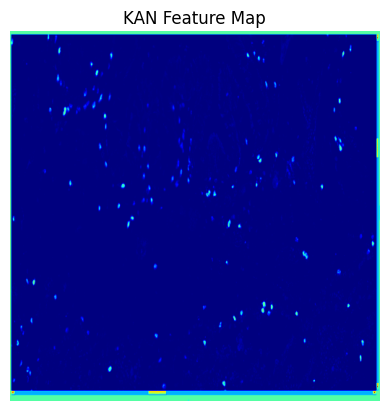

In [ ]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# Load image (no cv2)
img = Image.open("Image3.png").convert("L")  # convert to grayscale
img = img.resize((512, 512))

# Convert to tensor
img_np = np.array(img) / 255.0
tensor = torch.tensor(img_np).float().unsqueeze(0).unsqueeze(0)

# KAN Feature Extractor
kan = KAN(width=[1, 16], grid=8)

features = kan(tensor).detach().squeeze(0)

plt.imshow(features[0], cmap="jet")
plt.title("KAN Feature Map")
plt.axis("off")
plt.show()


In [6]:
pip install cellpose

  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Using cached segment_anything-1.0-py3-none-any.whl.metadata (487 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 652.6/652.6 kB 10.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 10.1 MB/s  0:00:01m0:00:0100:01
Using cached natsort-8.4.0-py3-none-any.whl (38 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 MB 9.2 MB/s  0:00:05m0:00:0100:01m
Using cached segment_anything-1.0-py3-none-any.whl (36 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [cellpose]5/9 [imagecodecs]n-headless]
Note: you may need to restart the kernel to use updated packages.


In [1]:
from cellpose import models
model = models.CellposeModel(model_type='cyto2', gpu=False)


model_type argument is not used in v4.0.1+. Ignoring this argument...
100%|██████████| 1.15G/1.15G [01:35<00:00, 12.9MB/s]


In [5]:
from cellpose import models, io
from cellpose.io import imread

io.logger_setup()

model = models.CellposeModel(gpu=True)

2026-01-28 11:35:37,093 [INFO] WRITING LOG OUTPUT TO /Users/akarshpatil/.cellpose/run.log
2026-01-28 11:35:37,095 [INFO] 
cellpose version: 	4.0.8 
platform:       	darwin 
python version: 	3.10.1 
torch version:  	2.9.1
2026-01-28 11:35:37,155 [INFO] ** TORCH MPS version installed and working. **
2026-01-28 11:35:37,155 [INFO] >>>> using GPU (MPS)
2026-01-28 11:35:42,237 [INFO] >>>> loading model /Users/akarshpatil/.cellpose/models/cpsam


In [9]:
import os

image_filename = "Image1 (1).png"

# Check if the image file exists
if not os.path.exists(image_filename):
    print(f"ERROR: Image file '{image_filename}' not found.")
    print("Please ensure the image file is in the current directory or provide the correct path.")
    # Set img to None to handle the missing file case gracefully
    img = None
else:
    img = io.imread(image_filename)

# Only proceed with model evaluation if the image was successfully loaded
if img is not None:
    masks, flows, styles = model.eval(
        img,
        channels=[0,0],

    )
    print("Segmentation completed successfully.")
else:
    print("Image not loaded, skipping segmentation.")


if 'masks' in locals() and masks is not None:
    plt.figure(figsize=(8, 8))
    plt.imshow(masks)
    plt.title("Cellpose Segmentation Masks")
    plt.axis("off")
    plt.show()
else:
    print("No masks to display. Please ensure segmentation was successful.")


2026-01-28 11:53:51,054 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-01-28 11:53:51,071 [INFO] processing image with (888, 1844) HW, and 3 channels


KeyboardInterrupt: 

In [ ]:


# metrics.py

import numpy as np
import cv2


#  Computing fourier descriptors for contours of all 4 images as masks

def get_contours(mask):
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    return contours
def contour_to_fourier(cnt):
    pts = cnt[:, 0, :]
    z = pts[:, 0] + 1j * pts[:, 1]
    return np.fft.fft(z)
def lowpass_filter(F, keep=15):
    F_filtered = np.zeros_like(F)
    F_filtered[:keep] = F[:keep]
    F_filtered[-keep:] = F[-keep:]
    return F_filtered
def fourier_to_contour(F):
    z = np.fft.ifft(F)
    pts = np.vstack((z.real, z.imag)).T
    return pts.astype(np.int32)
def fourier_smooth(mask, keep=15, min_area=30):
    new_mask = np.zeros_like(mask)

    contours = get_contours(mask)

    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue

        F = contour_to_fourier(cnt)
        F_filt = lowpass_filter(F, keep=keep)
        smooth_cnt = fourier_to_contour(F_filt)

        cv2.drawContours(new_mask, [smooth_cnt], -1, 1, -1)

    return new_mask.astype(bool)



raw_mask, _ = segment_image(img, channel="blue", method="cellpose")

refined_mask = fourier_smooth(raw_mask, keep=20)




def compute_iou(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask)
    union = np.logical_or(pred_mask, true_mask)
    iou_score = np.sum(intersection) / np.sum(union)
    return iou_score




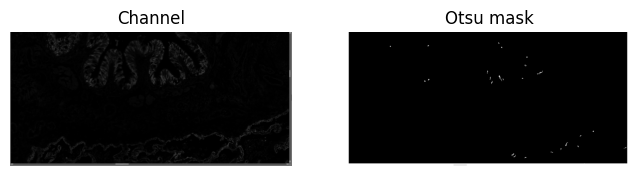

In [15]:

import cv2
import numpy as np
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('Image5.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Choose channel (0=red, 1=green, 2=blue)
channel = img[:, :, 2]   # blue channel

# Otsu threshold
t = threshold_otsu(channel)
binary = channel > t

# Clean mask
binary = remove_small_objects(binary, min_size=30)
binary = remove_small_holes(binary, area_threshold=50)

# Visualise
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Channel")
plt.imshow(channel, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Otsu mask")
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.show()
